### Step 1) Signal specific preprocessing (filtering) and Step 2): Segmentation

In [ ]:
import pandas as pd
import numpy as np
import os
import h5py
import re
from scipy.signal import butter, filtfilt

# ---------------- SETTINGS ----------------
window_sec = 30  # epoch length in seconds

psg_folder = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\PSG"
act_folder = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Actigraph Raw"
output_h5 = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step1_preprocessed_signals_TEST.h5"

# ---------------- FILTER HELPERS ----------------
def bandpass(signal, low, high, fs, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

def lowpass(signal, cutoff, fs, order=4):
    b, a = butter(order, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, signal)

# ---------------- SIGNAL-SPECIFIC FILTERING ----------------
def preprocess_signal(signal, name, fs_channel):
    name = name.lower()

    if "c3" in name or "c4" in name:       # EEG
        return bandpass(signal, 0.3, 35, fs_channel)  #bandpass filter that keeps only frequencies between 0.3 Hz and 35 Hz
                                                      #and removes everything outside that range

    elif "eog" in name:                     # EOG
        return bandpass(signal, 0.1, 15, fs_channel)

    elif "emg" in name:                     # EMG                               
        high_cut = min(100, fs_channel/2 - 1e-3)
        filtered = bandpass(signal, 10, high_cut, fs_channel)
        return np.abs(filtered)
                                                                                #Remove low-frequency noise (<10 Hz).
                                                                                #Keep the high-frequency muscle activity up to Nyquist (or 100 Hz max).
                                                                                #Rectify the signal to make it suitable for RMS and other amplitude-based features.
    elif "ecg" in name:                     # ECG go lower 
        return bandpass(signal, 0.6, 20, fs_channel) #not 5

    elif "thorax" in name:                  # Thorax / Respiration
        return lowpass(signal, 2, fs_channel)

    else:                                   # SpO2 / Pulse / Position / Accuracy / Pleth?
        return signal

# ---------------- EXPECTED PSG CHANNEL NAMES ----------------
psg_channel_names = [
    "EOG1", "EOG2", "EOG1_A2", "EOG2_A1", "EOG2_A2",
    "C3", "C4", "A1", "A2", "C3_A2", "C4_A1",
    "EMG", "ECG", "Thorax", "SpO2", "Pleth",
    "Pulse", "Magnitude", "Position", "Accuracy"
]

# ---------------- MAIN PIPELINE ----------------
with h5py.File(output_h5, 'w') as h5f:

    for file_name in os.listdir(psg_folder):
        if not file_name.endswith((".txt", ".csv")):
            continue

        print(f"\nProcessing {file_name}...")

        psg_path = os.path.join(psg_folder, file_name)
        psg_data = pd.read_csv(psg_path)

        signal_columns = psg_data.columns[1:21]  # take first 20 columns
        n_cols = len(signal_columns)

        if n_cols != len(psg_channel_names):
            print(f"⚠️ {file_name} has {n_cols} PSG columns, expected 20. Mapping positionally anyway.")

        # Determine number of epochs
        n_samples = len(psg_data)
        fs_default = 256  # assume PSG is at 256 Hz
        n_windows = n_samples // (fs_default * window_sec)

        grp = h5f.create_group(file_name.replace(".txt", ""))

        # ---------------- PROCESS PSG ----------------
        for idx, col in enumerate(signal_columns):
            raw_signal = psg_data[col].values

            # Map column index to channel name
            if idx < len(psg_channel_names):
                channel_name = psg_channel_names[idx]
            else:
                channel_name = f"unknown_{idx+1}"

            # ---------------- SET CHANNEL-SPECIFIC FS ----------------
            if "ECG" in channel_name or "EMG" in channel_name or "EOG" in channel_name or "C3" in channel_name or "C4" in channel_name:
                fs_ch = 256
            elif "Thorax" in channel_name or "SpO2" in channel_name or "Pulse" in channel_name or "Pleth" in channel_name:
                fs_ch = 100  # adjust if actual sampling rate is known
            else:
                fs_ch = 256  # default

            # Preprocess
            processed = preprocess_signal(raw_signal, channel_name, fs_ch)

            # Segment into 30-sec windows
            window_samples = fs_ch * window_sec
            segments = np.array([
                processed[i*window_samples:(i+1)*window_samples]
                for i in range(n_windows)
            ], dtype=np.float32)

            grp.create_dataset(f"PSG/{channel_name}", data=segments, compression="gzip")

        print("PSG processed.")

        # ---------------- PROCESS ACTIGRAPHY ----------------
        match = re.search(r"NUS\d+", file_name)
        if not match:
            continue

        subject_id = match.group(0)

        matching_act = None
        for act_file in os.listdir(act_folder):
            if subject_id in act_file:
                matching_act = os.path.join(act_folder, act_file)
                break

        if matching_act is None:
            continue

        act_data = pd.read_csv(matching_act)
        act_cols = [c for c in act_data.columns if "Accelerometer" in c]

        act_fs = 60
        n_act_windows = len(act_data) // (act_fs * window_sec)

        for col in act_cols:
            signal = act_data[col].values

            segments = np.array([
                signal[i*act_fs*window_sec:(i+1)*act_fs*window_sec]
                for i in range(n_act_windows)
            ], dtype=np.float32)

            grp.create_dataset(f"Actigraphy/{col}", data=segments, compression="gzip")

        print("Actigraphy segmented at high resolution.")

print("\n✅ Step 1: Signal-specific preprocessing complete.")



Processing NUS3001_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3002_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3003_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3004_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3005_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3006_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3007_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3008_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3009_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy segmented at high resolution.

Processing NUS3010_N1_epoched_(1)_data.txt...
PSG processed.
Actigraphy 

##### Checking why there's NaN values for some PSG (thorax, pulse, magnitude etc) signals

In [ ]:
import pandas as pd
import numpy as np

# 🔹 Load ONE original PSG file 
psg_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\PSG\NUS3004_N1_epoched_(1)_data.txt"

psg_data = pd.read_csv(psg_path)

print("\n===== COLUMN OVERVIEW =====\n")

for col in psg_data.columns:
    
    total_samples = len(psg_data[col])
    nan_count = psg_data[col].isna().sum()
    nan_percent = (nan_count / total_samples) * 100
    
    print(f"Channel: {col}")
    print(f"  Total samples: {total_samples}")
    print(f"  NaN count: {nan_count}")
    print(f"  NaN percentage: {nan_percent:.2f}%")
    print("-" * 40)



===== COLUMN OVERVIEW =====

Channel: Time
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 1
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 2
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 3
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 4
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 5
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 6
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 7
  Total samples: 6497280
  NaN count: 0
  NaN percentage: 0.00%
----------------------------------------
Channel: 8
  Total samples: 6497280
  N

##### Plot before and after filtering

Channel 1 (col 5): Original -> min=-600.000, max=600.000, mean=0.293
Channel 1 (col 5): Filtered -> min=-322.660, max=345.336, mean=0.000
-------------------------------------------------
Channel 2 (col 6): Original -> min=0.000, max=6.000, mean=0.016
Channel 2 (col 6): Filtered -> min=-6.738, max=1.518, mean=-0.000
-------------------------------------------------
Channel 3 (col 7): Original -> min=-600.000, max=600.000, mean=0.144
Channel 3 (col 7): Filtered -> min=-484.699, max=459.822, mean=-0.000
-------------------------------------------------


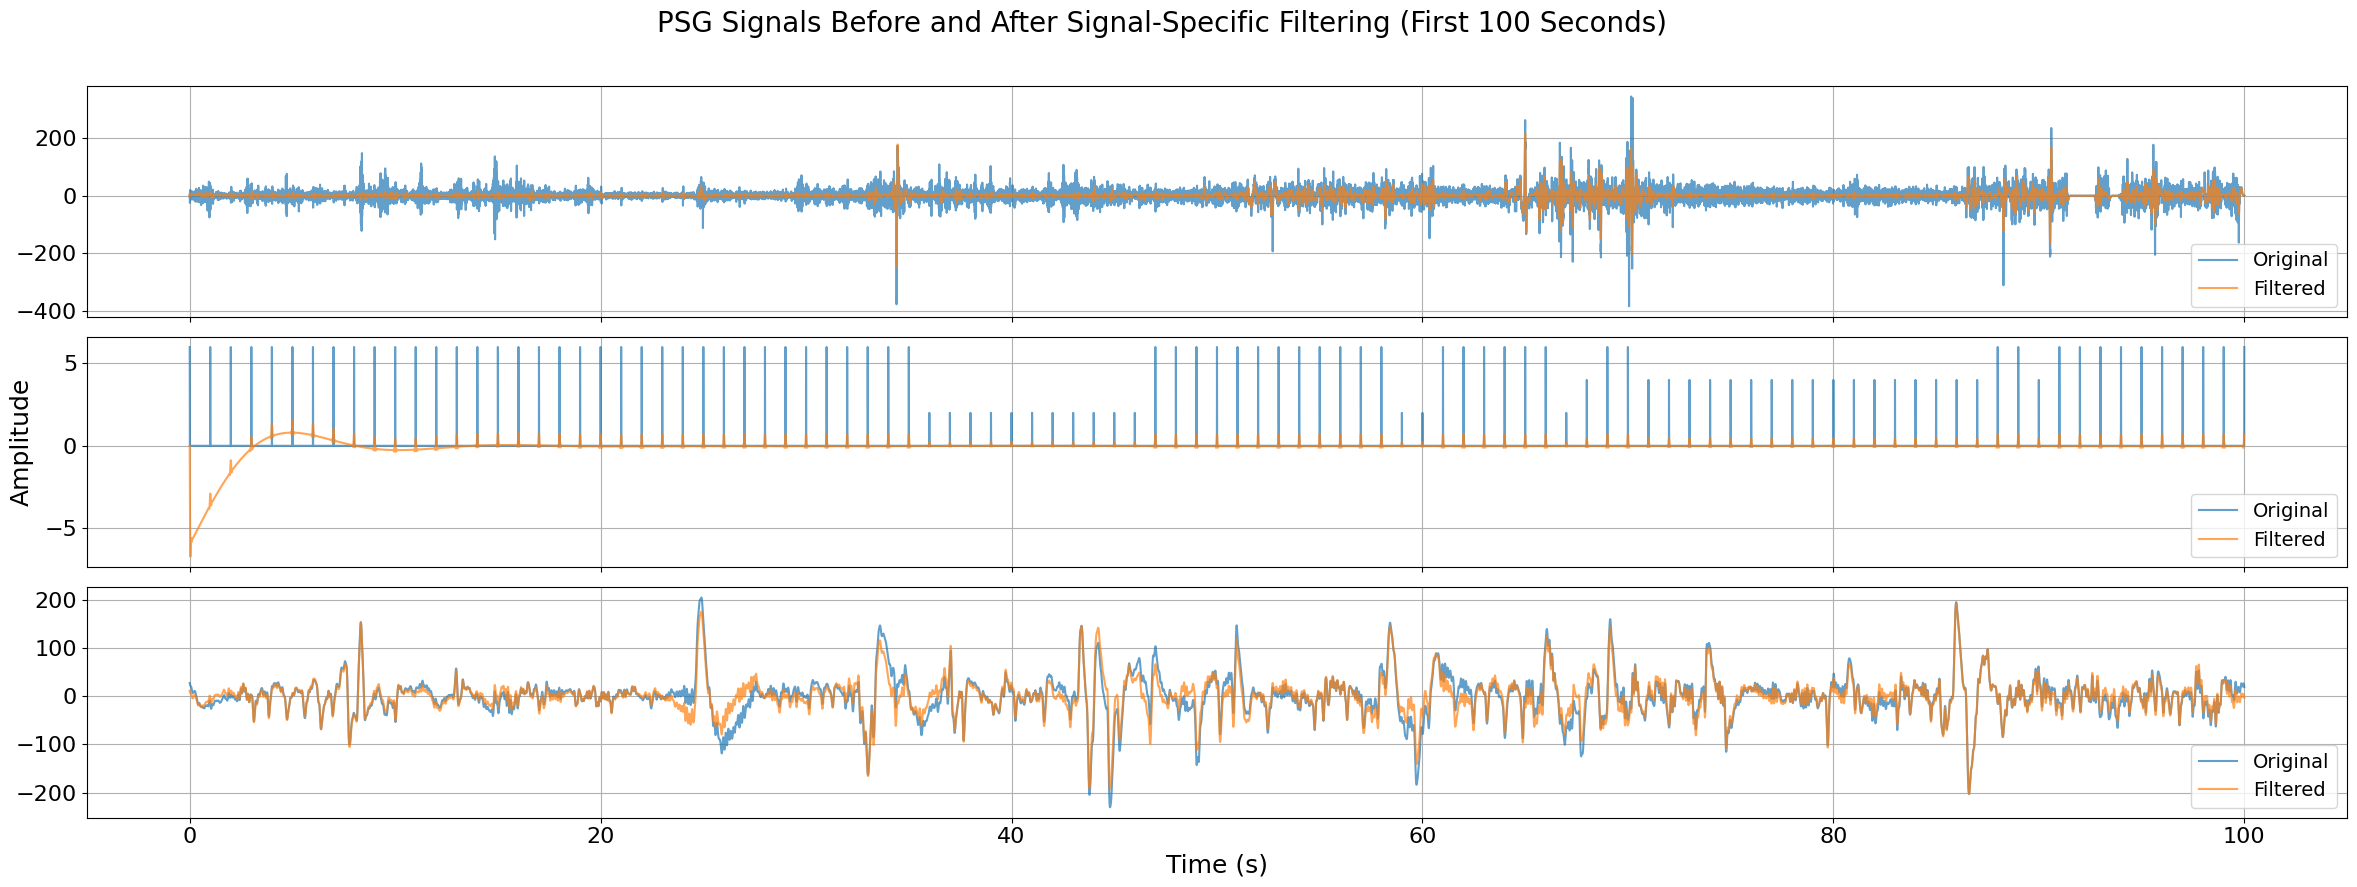

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- SETTINGS ----------------
fs = 256  # assumed sampling rate
file_path = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\PSG\NUS3001_N1_epoched_(1)_data.txt"

# ---------------- FILTER FUNCTIONS (from your new pipeline) ----------------
from scipy.signal import butter, filtfilt

def bandpass(signal, low, high, fs, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

def lowpass(signal, cutoff, fs, order=4):
    b, a = butter(order, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, signal)

def preprocess_signal(signal, name, fs_channel):
    # Since we only have numbers, let's just map channels by index (first 3)
    if name in [1, 2]:       # simulate EOG1, EOG2
        return bandpass(signal, 0.1, 15, fs_channel)
    elif name == 3:           # simulate C3
        return bandpass(signal, 0.3, 35, fs_channel)
    else:                     # rest of channels, just pass
        return signal

# ---------------- LOAD DATA ----------------
data = pd.read_csv(file_path, sep=',', header=0)
data = data.fillna(0)

# Time vector
time = np.arange(len(data)) / fs

# Select first 10 seconds
mask = time <= 100
time_100s = time[mask]

# Select channels to plot (first 3 columns for simplicity)
channels = data.columns[5:8]  # this keeps your numeric or default headers
#channels = [data.columns[5], data.columns[6], data.columns[8]]
# ---------------- APPLY FILTER ----------------
filtered_data = data.copy()
for i, ch in enumerate(channels, start=1):
    filtered_data[ch] = preprocess_signal(data[ch].values, i, fs)

# ---------------- PRINT SIMPLE STATS ----------------
for i, ch in enumerate(channels, start=1):
    orig = data[ch].values
    filt = filtered_data[ch].values
    print(f"Channel {i} (col {ch}): Original -> min={orig.min():.3f}, max={orig.max():.3f}, mean={orig.mean():.3f}")
    print(f"Channel {i} (col {ch}): Filtered -> min={filt.min():.3f}, max={filt.max():.3f}, mean={filt.mean():.3f}")
    print("-------------------------------------------------")

fig, axes = plt.subplots(len(channels), 1, figsize=(24, 3*len(channels)), sharex=True)

for i, ch in enumerate(channels):
    axes[i].plot(time_100s, data[ch].values[mask], label='Original', alpha=0.7)
    axes[i].plot(time_100s, filtered_data[ch].values[mask], label='Filtered', alpha=0.7)
    axes[i].grid(True)
    axes[i].legend(loc='lower right', fontsize=14)
    axes[i].tick_params(axis='both', labelsize=16)

fig.supylabel("Amplitude", fontsize=18)   # ✅ centered for whole figure
axes[-1].set_xlabel('Time (s)', fontsize=18)

plt.suptitle('PSG Signals Before and After Signal-Specific Filtering (First 100 Seconds)', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Step 3) Feature extraction

### USE THIS ONE (correct printing, handling NaN, feature_names)

In [29]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import butter, filtfilt, welch
import neurokit2 as nk

# ---------------- SETTINGS ----------------
fs_default = 100  # default for feature extraction (most EEG/Actigraphy will be resampled/assumed)
input_hdf5 = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step1_preprocessed_signals_TEST.h5"
labels_folder = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\ConsensusSleepStaging"
output_hdf5 = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step3_Feature_extraction_NEW3.h5"

# ---------------- BAND DEFINITIONS ----------------
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30)
}

# ---------------- FEATURE FUNCTIONS ----------------
def extract_psg_features(segment, channel_type="EEG", fs=fs_default):
    segment = np.asarray(segment)
    feats = {}
    # Time-domain
    feats["mean"] = np.mean(segment)
    feats["std"] = np.std(segment)
    feats["var"] = np.var(segment)
    feats["min"] = np.min(segment)
    feats["max"] = np.max(segment)
    # Spectral
    f, Pxx = welch(segment, fs=fs, nperseg=fs*2)
    feats["spectral_centroid"] = np.sum(f * Pxx) / np.sum(Pxx) if np.sum(Pxx) != 0 else 0
    # Bandpowers
    for band_name, (low, high) in bands.items():
        feats[f"bandpower_{band_name}"] = np.sum(Pxx[(f >= low) & (f < high)])
    # Ratios
    if channel_type in ["EEG", "EOG"]:
        feats["theta_delta_ratio"] = feats["bandpower_theta"]/feats["bandpower_delta"] if feats["bandpower_delta"]>0 else np.nan
        feats["alpha_beta_ratio"] = feats["bandpower_alpha"]/feats["bandpower_beta"] if feats["bandpower_beta"]>0 else np.nan
    return feats

def extract_emg_features(signal):
    signal = np.asarray(signal)
    rect = np.abs(signal)
    smooth = pd.Series(rect).rolling(50, min_periods=1, center=True).mean().values
    return {
        "rms": np.sqrt(np.mean(smooth**2)),
        "skew": skew(smooth, nan_policy='omit'),
        "kurtosis": kurtosis(smooth, nan_policy='omit')
    }

def extract_ecg_features(signal, fs=fs_default):
    signal = np.asarray(signal)
    try:
        ecg_clean = nk.ecg_clean(signal, sampling_rate=fs)
        rpeaks_dict = nk.ecg_peaks(ecg_clean, sampling_rate=fs)[1] if len(nk.ecg_peaks(ecg_clean, sampling_rate=fs))>1 else nk.ecg_peaks(ecg_clean, sampling_rate=fs)
        rpeaks_idx = rpeaks_dict["ECG_R_Peaks"]
        if len(rpeaks_idx)<2:
            raise ValueError("Too few R-peaks")
        rr = np.diff(rpeaks_idx)/fs
        hr = 60/rr
        return {
            "R_peak_count": len(rpeaks_idx), #Number of heartbeats
            "HR_mean": np.mean(hr),          #mean heart rate (HR=60/RR)
            "HR_std": np.std(hr),            #Heart rate variability
            "RR_mean": np.mean(rr),          #Average time between beats
            "RR_std": np.std(rr),            #Variation in beat timing
            "RMSSD": np.sqrt(np.mean(np.diff(rr)**2)) if len(rr)>1 else np.nan #Short-term heart variability, used in sleep, stress and cardiology researc
        }
    except Exception:
        return {k: np.nan for k in ["R_peak_count","HR_mean","HR_std","RR_mean","RR_std","RMSSD"]}
                           
def extract_resp_features(signal, fs=fs_default):
    signal = np.asarray(signal)
    filtered = filtfilt(*butter(4, [0.1/(0.5*fs), 2/(0.5*fs)], btype="band"), signal)
    peaks_df = nk.signal_findpeaks(filtered)
    return {
        "mean": np.mean(filtered),
        "std": np.std(filtered),
        "breath_count": peaks_df["Peaks"].sum()
    }

def extract_spo2_pulse_features(signal):
    signal = np.asarray(signal)
    smooth = pd.Series(signal).rolling(50, min_periods=1, center=True).mean().values
    peaks_df = nk.signal_findpeaks(smooth)
    return {
        "mean": np.mean(smooth),
        "std": np.std(smooth),
        "peak_count": peaks_df["Peaks"].sum()
    }

def process_actigraphy(signal):
    signal = np.asarray(signal)
    if np.all(np.isnan(signal)):
        return {}
    return {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "var": np.var(signal),
        "min": np.min(signal),
        "max": np.max(signal),
        "VM": np.sqrt(np.sum(signal**2))
    }

# ---------------- LOAD LABELS ----------------
labels_dict = {}
for file in os.listdir(labels_folder):
    if file.endswith(".csv") or file.endswith(".txt"):
        df = pd.read_csv(os.path.join(labels_folder,file), header=None)
        labels_dict[file.split(".")[0]] = df.values.flatten()

def find_matching_label(subject_name):
    clean_name = subject_name.split("_epoched")[0]
    for key in labels_dict.keys():
        if key.startswith(clean_name) or clean_name.startswith(key):
            return key
    return None

# ---------------- EXPECTED PSG CHANNELS ----------------

expected_psg_channels = [
    # EEG
    "C3_A2", "C4_A1", "C3", "C4",
    # EOG
    "EOG1", "EOG2", "EOG1_A2", "EOG2_A1", "EOG2_A2",
    # Reference
    "A1", "A2",
    # Musche and heart
    "EMG", "ECG", 
    #Breathing/oxygen
    "Thorax", "SpO2", "Pulse", "Pleth",
    # Actigraphy-like PSG signals
    "Magnitude", "Position", "Accuracy"
]


# ---------------- MAIN FEATURE EXTRACTION ----------------
with h5py.File(input_hdf5, 'r') as h5in, h5py.File(output_hdf5,'w') as h5out:
    for subj in h5in.keys():
        print(f"\nProcessing {subj}")
        subj_grp = h5in[subj]

        # Match label
        label_key = find_matching_label(subj)
        if label_key is None:
            print(f"⚠️ No labels found for {subj}, skipping.")
            continue
        y_array = labels_dict[label_key]

        all_features = []
        feature_names = []

        # ---------------- PSG ----------------
        if "PSG" in subj_grp:
            # Automatic mapping: detect channels by name
            ch_mapping = {}
            for ch_name in subj_grp["PSG"].keys():
                for exp_ch in expected_psg_channels:
                    if exp_ch.lower() in ch_name.lower():
                        ch_mapping[exp_ch] = ch_name
                        break
        
            # Iterate over epochs
            # n_epochs = next(iter(subj_grp["PSG"].values())).shape[0]
            # for epoch_idx in range(n_epochs):
            #     epoch_feat = {}
            #     for ch_type, mapped_name in ch_mapping.items():
            #         seg = subj_grp["PSG"][mapped_name][epoch_idx]
            #         if ch_type in ["C3","C4","EOG1","EOG2"]:
            #             feats = extract_psg_features(seg, channel_type=ch_type)
            #         elif ch_type=="EMG":
            #             feats = extract_emg_features(seg)
            #         elif ch_type=="ECG":
            #             feats = extract_ecg_features(seg)
            #         elif ch_type in ["Thorax","Abdomen"]:
            #             feats = extract_resp_features(seg)
            #         elif ch_type in ["SpO2","Pulse","Pleth"]:
            #             feats = extract_spo2_pulse_features(seg)
            #         else:
            #             feats = extract_psg_features(seg, channel_type=ch_type)
            #         for k,v in feats.items():
            #             epoch_feat[f"{ch_type}_{k}"] = v
            #     all_features.append(epoch_feat)
            #     feature_names.extend(epoch_feat.keys())
               # Iterate over epochs
            n_epochs = next(iter(subj_grp["PSG"].values())).shape[0]

            for epoch_idx in range(n_epochs):
                epoch_feat = {}

                for ch_type, mapped_name in ch_mapping.items():
                    seg = subj_grp["PSG"][mapped_name][epoch_idx]

                    # ---------------- EEG -------------Handles all EEG variants
                    if any(eeg in ch_type for eeg in ["C3", "C4", "A1", "A2"]):
                        feats = extract_psg_features(seg, channel_type="EEG")

                    # ---------------- EOG -------------Handles all EOG variants (EOG1, EOG2, EOG1_A2, etc.)
                    elif "EOG" in ch_type:
                        feats = extract_psg_features(seg, channel_type="EOG")

                    # ---------------- EMG ----------------
                    elif ch_type == "EMG":
                        feats = extract_emg_features(seg)

                    # ---------------- ECG ----------------
                    elif ch_type == "ECG":
                        feats = extract_ecg_features(seg)

                    # ---------------- Respiration ----------------
                    elif ch_type in ["Thorax"]:
                        feats = extract_resp_features(seg)

                    # ---------------- Oxygen / Pulse ----------------
                    elif ch_type in ["SpO2", "Pulse", "Pleth"]:
                        feats = extract_spo2_pulse_features(seg)

                    # ---------------- Actigraphy-like ----------------
                    elif ch_type in ["Magnitude", "Position", "Accuracy"]:
                        feats = process_actigraphy(seg)

                    # ---------------- Fallback ----------------
                    else:
                        feats = extract_psg_features(seg, channel_type="GEN")

                    # Store features with channel prefix
                    for k, v in feats.items():
                        epoch_feat[f"{ch_type}_{k}"] = v

                all_features.append(epoch_feat)

                # Only define feature names once (Prevents duplicated feature names)
                if epoch_idx == 0:
                    feature_names = list(epoch_feat.keys())

        # ---------------- ACTIGRAPHY (OLD) ----------------
        # if "Actigraphy" in subj_grp:
        #     n_epochs_act = next(iter(subj_grp["Actigraphy"].values())).shape[0]
        #     for epoch_idx in range(n_epochs_act):
        #         epoch_feat = {}
        #         for col in subj_grp["Actigraphy"].keys():
        #             seg = subj_grp["Actigraphy"][col][epoch_idx,:]
        #             feats = process_actigraphy(seg)
        #             for k,v in feats.items():
        #                 epoch_feat[f"{col}_{k}"] = v
        #         all_features.append(epoch_feat)
        #         feature_names.extend(epoch_feat.keys())

        # ---------------- Actigraphy inside main epoch loop ----------------
        actigraphy_channels = {"X":"Accelerometer X", "Y":"Accelerometer Y", "Z":"Accelerometer Z"}

        if "Actigraphy" in subj_grp:
            n_epochs_act = next(iter(subj_grp["Actigraphy"].values())).shape[0]
            for epoch_idx in range(n_epochs_act):
                # Check if we already have a dict for this epoch
                if len(all_features) < epoch_idx + 1:
                    all_features.append({})

                epoch_feat = all_features[epoch_idx]

                for col in subj_grp["Actigraphy"].keys():
                    seg = subj_grp["Actigraphy"][col][epoch_idx,:]
                    feats = process_actigraphy(seg)
                    
                    # Rename keys
                    if col in actigraphy_channels:
                        prefix = actigraphy_channels[col]
                    else:
                        prefix = col  # fallback
                    for k,v in feats.items():
                        epoch_feat[f"{prefix}_{k}"] = v


        # ---------------- ALIGN & SAVE (OLD) ----------------
        # if len(all_features)>0:
        #     df = pd.DataFrame(all_features)
        #     min_rows = min(len(y_array), len(df))
        #     df = df.iloc[:min_rows]
        #     y_clean = y_array[:min_rows]

        #     subj_out = h5out.create_group(subj)
        #     subj_out.create_dataset("X_combined", data=df.values.astype(np.float32), compression="gzip")
        #     dt = h5py.string_dtype(encoding="utf-8")
        #     subj_out.create_dataset("feature_names", data=np.array(df.columns, dtype=object), dtype=dt)
        #     subj_out.create_dataset("y", data=y_clean)
           # ---------------- ALIGN ----------------
        df = pd.DataFrame(all_features)

        min_rows = min(len(y_array), len(df))
        df = df.iloc[:min_rows]
        y_clean = y_array[:min_rows]

        # ---------------- REMOVE ROWS WITH TOO MANY NaNs ----------------
        row_nan = df.isna().mean(axis=1)

        # Keep rows where less than 80% of features are NaN (thats why accuracy, position and magnitude is not printed)
        mask = row_nan < 0.8

        df = df[mask]
        y_clean = y_clean[mask]

        print(f"Removed {np.sum(~mask)} epochs with >80% missing features.")

        # ---------------- OPTIONAL: REMOVE HIGHLY MISSING FEATURES ----------------
        col_nan = df.isna().mean()

        # Remove features missing in more than 50% of epochs
        df = df.loc[:, col_nan < 0.5]

        print(f"Remaining epochs: {df.shape[0]}")
        print(f"Remaining features: {df.shape[1]}")

        # ---------------- SAVE ----------------
        subj_out = h5out.create_group(subj)
        subj_out.create_dataset("X_combined", data=df.values.astype(np.float32), compression="gzip")

        dt = h5py.string_dtype(encoding="utf-8")
        subj_out.create_dataset("feature_names", data=np.array(df.columns, dtype=object), dtype=dt)
        subj_out.create_dataset("y", data=y_clean)

        print(f"✅ {subj} done ({min_rows} epochs)")

        
print("\n🎉 Step 3: Feature extraction complete!")



Processing NUS3001_N1_epoched_(1)_data
Removed 0 epochs with >80% missing features.
Remaining epochs: 899
Remaining features: 121
✅ NUS3001_N1_epoched_(1)_data done (899 epochs)

Processing NUS3002_N1_epoched_(1)_data
Removed 0 epochs with >80% missing features.
Remaining epochs: 870
Remaining features: 121
✅ NUS3002_N1_epoched_(1)_data done (870 epochs)

Processing NUS3003_N1_epoched_(1)_data
Removed 0 epochs with >80% missing features.
Remaining epochs: 949
Remaining features: 99
✅ NUS3003_N1_epoched_(1)_data done (949 epochs)

Processing NUS3004_N1_epoched_(1)_data
Removed 0 epochs with >80% missing features.
Remaining epochs: 846
Remaining features: 129
✅ NUS3004_N1_epoched_(1)_data done (846 epochs)

Processing NUS3005_N1_epoched_(1)_data
Removed 0 epochs with >80% missing features.
Remaining epochs: 720
Remaining features: 129
✅ NUS3005_N1_epoched_(1)_data done (720 epochs)

Processing NUS3006_N1_epoched_(1)_data
Removed 0 epochs with >80% missing features.
Remaining epochs: 888

# Step 4) Normalization

##### Normalization + train/test split

In [6]:
import os
import h5py
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd

# -------------------- Paths --------------------
input_hdf5 = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step3_Feature_extraction_NEW2.h5"
labels_folder = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\ConsensusSleepStaging"
output_hdf5 = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_NEW.h5"

# -------------------- Load labels --------------------
labels_dict = {}
for file in os.listdir(labels_folder):
    if file.endswith(".csv") or file.endswith(".txt"):
        filepath = os.path.join(labels_folder, file)
        df = np.array(pd.read_csv(filepath, header=None))
        key_name = file.split(".")[0]
        labels_dict[key_name] = df.flatten()
print(f"✅ Loaded labels for {len(labels_dict)} subjects.")

# -------------------- Z-score normalization --------------------
def zscore_normalize(x):
    """Z-score normalization with NaN handling."""
    x = np.nan_to_num(x, nan=0.0)  # replace NaN with 0
    mean = np.mean(x)
    std = np.std(x)
    if std == 0:
        return x - mean
    return (x - mean) / std

# -------------------- Load features and normalize --------------------
X_list = []
y_list = []

max_features = 0

# --- First pass: find max number of features ---
with h5py.File(input_hdf5, 'r') as h5f:
    for subj in h5f.keys():
        if "X_combined" not in h5f[subj]:
            print(f"⚠ No X_combined found for {subj}, skipping.")
            continue
        X_subj = h5f[subj]["X_combined"][:]
        if X_subj.ndim == 1:
            X_subj = X_subj[:, np.newaxis]  # make 2D
        max_features = max(max_features, X_subj.shape[1])
print(f"Maximum number of features across subjects: {max_features}")

# --- Second pass: normalize, pad, collect ---
with h5py.File(input_hdf5, 'r') as h5f:
    for subj in h5f.keys():
        # Match label
        label_key = None
        clean_name = subj.split("_epoched")[0]
        for key in labels_dict.keys():
            if key.startswith(clean_name):
                label_key = key
                break
        if label_key is None:
            print(f"⚠ No label match for {subj}, skipping.")
            continue

        y_subj = labels_dict[label_key]

        if "X_combined" not in h5f[subj]:
            print(f"⚠ No X_combined found for {subj}, skipping.")
            continue

        X_subj = h5f[subj]["X_combined"][:]
        if X_subj.ndim == 1:
            X_subj = X_subj[:, np.newaxis]  # ensure 2D

        # Trim to match label length
        n_rows = min(X_subj.shape[0], len(y_subj))
        X_subj = X_subj[:n_rows, :]
        y_subj = y_subj[:n_rows]

        # Remove any rows with NaN
        mask = ~np.isnan(X_subj).any(axis=1)
        X_subj = X_subj[mask]
        y_subj = y_subj[mask]

        # Normalize features per subject
        X_subj = np.array([zscore_normalize(col) for col in X_subj.T]).T  # normalize each feature

        # Pad features to match max_features
        if X_subj.shape[1] < max_features:
            pad_width = max_features - X_subj.shape[1]
            X_subj = np.hstack([X_subj, np.zeros((X_subj.shape[0], pad_width))])

        X_list.append(X_subj)
        y_list.append(y_subj)

# -------------------- Concatenate all subjects --------------------
X = np.vstack(X_list)
y = np.hstack(y_list)
print(f"Total samples: {X.shape[0]}, Total features: {X.shape[1]}")

# -------------------- Train/Test split --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -------------------- Save to HDF5 --------------------
with h5py.File(output_hdf5, 'w') as h5out:
    h5out.create_dataset("X_train", data=X_train, compression="gzip")
    h5out.create_dataset("X_test", data=X_test, compression="gzip")
    h5out.create_dataset("y_train", data=y_train, compression="gzip")
    h5out.create_dataset("y_test", data=y_test, compression="gzip")

print(f"🎯 Normalized train/test split saved to {output_hdf5}")

with h5py.File(input_hdf5, 'r') as h5f:
    for subj in h5f.keys():
        X_subj = h5f[subj]["X_combined"][:]
        print(subj, X_subj.shape)


✅ Loaded labels for 67 subjects.
Maximum number of features across subjects: 111
Total samples: 57205, Total features: 111
Train samples: 45764, Test samples: 11441
🎯 Normalized train/test split saved to C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_NEW.h5
NUS3001_N1_epoched_(1)_data (899, 103)
NUS3002_N1_epoched_(1)_data (870, 103)
NUS3003_N1_epoched_(1)_data (949, 89)
NUS3004_N1_epoched_(1)_data (846, 111)
NUS3005_N1_epoched_(1)_data (720, 111)
NUS3006_N1_epoched_(1)_data (888, 89)
NUS3007_N1_epoched_(1)_data (741, 111)
NUS3008_N1_epoched_(1)_data (937, 111)
NUS3009_N1_epoched_(1)_data (722, 111)
NUS3010_N1_epoched_(1)_data (970, 111)
NUS3011_N1_epoched_(1)_data (961, 111)
NUS3012_N1_epoched_(1)_data (964, 111)
NUS3013_N1_epoched_(1)_data (841, 111)
NUS3014_N1_epoched_(1)_data (883, 111)
NUS3015_N1_epoched_(1)_data (772, 111)
NUS3016_N1_epoched_(1)_data (811, 111)
NUS3017_N1_epoched_(1)_data (725, 111)
NUS3018_N1

### USE THIS ONE

In [30]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# -------------------- Paths --------------------
input_hdf5 = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step3_Feature_extraction_NEW3.h5"
labels_folder = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\ConsensusSleepStaging"
output_hdf5 = r"C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5"

# -------------------- Load labels --------------------
labels_dict = {}
for file in os.listdir(labels_folder):
    if file.endswith(".csv") or file.endswith(".txt"):
        filepath = os.path.join(labels_folder, file)
        df = pd.read_csv(filepath, header=None)
        labels_dict[file.split(".")[0]] = df.values.flatten()
print(f"✅ Loaded labels for {len(labels_dict)} subjects.")

# -------------------- Z-score normalization --------------------
def zscore_normalize(X):
    """Vectorized per-column z-score normalization with NaN handling."""
    means = np.nanmean(X, axis=0)
    stds = np.nanstd(X, axis=0)
    stds[stds == 0] = 1  # avoid division by zero
    X_norm = (X - means) / stds
    X_norm = np.nan_to_num(X_norm, nan=0.0)
    return X_norm

# -------------------- First pass: determine max number of features --------------------
max_features = 0
with h5py.File(input_hdf5, 'r') as h5f:
    for subj in h5f.keys():
        if "X_combined" not in h5f[subj]:
            continue
        X_subj = h5f[subj]["X_combined"][:]
        if X_subj.ndim == 1:
            X_subj = X_subj[:, np.newaxis]
        max_features = max(max_features, X_subj.shape[1])
print(f"Maximum number of features across subjects: {max_features}")

# -------------------- Second pass: normalize, pad, collect --------------------
X_list = []
y_list = []
feature_names_set = None  # store feature names from first subject

with h5py.File(input_hdf5, 'r') as h5f:
    for subj in h5f.keys():
        # Find label
        label_key = None
        clean_name = subj.split("_epoched")[0]
        for key in labels_dict.keys():
            if key.startswith(clean_name):
                label_key = key
                break
        if label_key is None:
            print(f"⚠ No label match for {subj}, skipping.")
            continue
        y_subj = labels_dict[label_key]

        if "X_combined" not in h5f[subj]:
            print(f"⚠ No X_combined found for {subj}, skipping.")
            continue

        X_subj = h5f[subj]["X_combined"][:]
        if X_subj.ndim == 1:
            X_subj = X_subj[:, np.newaxis]

        # Trim to match label length
        n_rows = min(X_subj.shape[0], len(y_subj))
        X_subj = X_subj[:n_rows, :]
        y_subj = y_subj[:n_rows]

        # Remove rows where almost everything is NaN
        row_nan = np.isnan(X_subj).mean(axis=1)
        mask = row_nan < 0.8
        X_subj = X_subj[mask]
        y_subj = y_subj[mask]

        if X_subj.shape[0] == 0:
            print(f"⚠ All rows NaN for {subj}, skipping.")
            continue

        # Normalize features per subject
        X_subj = zscore_normalize(X_subj)

        # Pad features to match max_features
        if X_subj.shape[1] < max_features:
            pad_width = max_features - X_subj.shape[1]
            X_subj = np.hstack([X_subj, np.zeros((X_subj.shape[0], pad_width))])

        X_list.append(X_subj)
        y_list.append(y_subj)

        # Save feature names from first subject
        if feature_names_set is None:
            if "feature_names" in h5f[subj]:
                feature_names_set = h5f[subj]["feature_names"][:].astype(str)
            else:
                feature_names_set = np.array([f"feat{i}" for i in range(max_features)])

# -------------------- Concatenate all subjects --------------------
X = np.vstack(X_list)
y = np.hstack(y_list)
print(f"Total samples: {X.shape[0]}, Total features: {X.shape[1]}")

# -------------------- Train/Test split --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -------------------- Save to HDF5 --------------------
with h5py.File(output_hdf5, 'w') as h5out:
    h5out.create_dataset("X_train", data=X_train, compression="gzip")
    h5out.create_dataset("X_test", data=X_test, compression="gzip")
    h5out.create_dataset("y_train", data=y_train, compression="gzip")
    h5out.create_dataset("y_test", data=y_test, compression="gzip")
    dt = h5py.string_dtype(encoding="utf-8")
    h5out.create_dataset("feature_names", data=np.array(feature_names_set, dtype=object), dtype=dt)

print(f"🎯 Normalized train/test split saved to {output_hdf5}")


✅ Loaded labels for 67 subjects.
Maximum number of features across subjects: 129
Total samples: 57998, Total features: 129
Train samples: 46398, Test samples: 11600
🎯 Normalized train/test split saved to C:\Users\anita\OneDrive - Universitetet i Oslo\Masteroppgave zzz\UOslo_March2025\Combined\Step4_normalized_train_test_FINAL.h5
